# Evaluation Metrics — Hands-On Notebook

This notebook is the main event for today's session. Theory stayed short on the slides — here, we actually **compute, compare, and break** accuracy, precision, recall, and F1, using real (if small/synthetic) data.

**What we'll do:**
1. Rebuild the pass/fail model from the regression session
2. Build its confusion matrix
3. Compute accuracy / precision / recall / F1 BY HAND, then confirm with scikit-learn
4. Run a live "accuracy trap" demo on an imbalanced dataset
5. Sweep the decision threshold and watch precision and recall trade off in real time

Run each cell top to bottom with **Shift + Enter**.

## Setup — Import the Libraries We'll Use

In [1]:
# pandas: lets us store and work with data in table form
import pandas as pd

# numpy: numerical tools -- we'll use it to generate synthetic data and sweep thresholds
import numpy as np

# matplotlib: the library we'll use to draw charts
import matplotlib.pyplot as plt

# train_test_split: splits data into training and testing portions
from sklearn.model_selection import train_test_split

# LogisticRegression: the real model we'll train and evaluate
from sklearn.linear_model import LogisticRegression

# DummyClassifier: a "fake" model that ignores the data and just guesses --
# we'll use it later to expose the accuracy trap
from sklearn.dummy import DummyClassifier

# every metric we're covering today, all in one import
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

print("All libraries loaded successfully!")

All libraries loaded successfully!


# Part 1 — Rebuild Our Model

Quick refresher: we're reusing the `hours studied -> passed (0/1)` dataset and Logistic Regression model from the last session, so we have real predictions to evaluate.

In [2]:
# Same dataset as the regression session: hours studied, and whether the student passed.
data = pd.DataFrame({
    "hours": [1, 2, 3, 4, 5, 6, 7, 8, 9, 2.5, 5.5, 7.5],
    "passed": [0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1]
})

X = data[["hours"]]   # features
y = data["passed"]    # target: 0 = fail, 1 = pass

data   # display the table

,hours,passed
0,1.0,0
1,2.0,0
2,3.0,0
3,4.0,0
4,5.0,1
5,6.0,1
6,7.0,1
7,8.0,1
8,9.0,1
9,2.5,0


In [3]:
# Split into training and test sets, same as before.
# We're using a slightly bigger dataset this time (12 rows) so the test set has a few more examples to evaluate.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42
)

print("Training rows:", len(X_train))
print("Test rows:", len(X_test))

Training rows: 8
Test rows: 4


In [4]:
# Train the model -- exactly like last time.
model = LogisticRegression()
model.fit(X_train, y_train)

# Get the model's final 0/1 predictions on the test set.
predictions = model.predict(X_test)

# Get the underlying probabilities too -- we'll need these later for the threshold sweep.
probabilities = model.predict_proba(X_test)[:, 1]   # keep just the "probability of passing" column

print("Model trained and predictions made!")

Model trained and predictions made!


## Look at the Predictions

In [5]:
# Build a comparison table so we can see, row by row, what the model got right and wrong.
comparison = pd.DataFrame({
    "hours": X_test["hours"].values,
    "actual": y_test.values,
    "predicted": predictions,
    "probability_of_pass": probabilities.round(2)
})

comparison

,hours,actual,predicted,probability_of_pass
0,5.5,1,1,0.77
1,2.5,0,0,0.09
2,1.0,0,0,0.02
3,9.0,1,1,1.00


# Part 2 — The Confusion Matrix

Every metric today is built from just four numbers: True Positives, True Negatives, False Positives, and False Negatives. Let's generate them.

In [6]:
# confusion_matrix compares the actual labels to the predicted labels.
# By scikit-learn's convention: rows = actual, columns = predicted.
cm = confusion_matrix(y_test, predictions)

print("Raw confusion matrix:\n", cm)

Raw confusion matrix:
 [[2 0]
 [0 2]]


In [25]:
# Wrap it in a labeled table so it's easy to read at a glance.
cm_labeled = pd.DataFrame(
    cm,
    index=["Actual: Fail", "Actual: Pass"],
    columns=["Predicted: Fail", "Predicted: Pass"]
)

cm_labeled

,Predicted: Fail,Predicted: Pass
Actual: Fail,2,0
Actual: Pass,0,2


In [8]:
# .ravel() flattens the 2x2 matrix into a single list, in this fixed order: TN, FP, FN, TP.
# This is the standard scikit-learn order for a 2-class confusion matrix.
tn, fp, fn, tp = cm.ravel()

print("True Negatives  (TN):", tn)   # correctly predicted "fail"
print("False Positives (FP):", fp)   # wrongly predicted "pass"
print("False Negatives (FN):", fn)   # wrongly predicted "fail"
print("True Positives  (TP):", tp)   # correctly predicted "pass"

True Negatives  (TN): 2
False Positives (FP): 0
False Negatives (FN): 0
True Positives  (TP): 2


# Part 3 — Compute the Metrics by Hand

Now let's turn those four numbers into accuracy, precision, recall, and F1 -- using the exact formulas from the slides, written out in code.

In [9]:
# Accuracy = (TP + TN) / Total -- how much did we get right, overall?
total = tn + fp + fn + tp
accuracy_manual = (tp + tn) / total

print("Accuracy (by hand):", round(accuracy_manual, 3))

Accuracy (by hand): 1.0


In [10]:
# Precision = TP / (TP + FP) -- of everything we predicted "pass", how much was right?
# We guard against dividing by zero, in case the model never predicts "pass" at all.
precision_manual = tp / (tp + fp) if (tp + fp) > 0 else 0

print("Precision (by hand):", round(precision_manual, 3))

Precision (by hand): 1.0


In [11]:
# Recall = TP / (TP + FN) -- of everyone who actually passed, how much did we catch?
recall_manual = tp / (tp + fn) if (tp + fn) > 0 else 0

print("Recall (by hand):", round(recall_manual, 3))

Recall (by hand): 1.0


In [12]:
# F1 = 2 * (Precision * Recall) / (Precision + Recall) -- the harmonic mean of the two.
if (precision_manual + recall_manual) > 0:
    f1_manual = 2 * (precision_manual * recall_manual) / (precision_manual + recall_manual)
else:
    f1_manual = 0   # if both precision and recall are 0, F1 is defined as 0

print("F1 Score (by hand):", round(f1_manual, 3))

F1 Score (by hand): 1.0


## Now Check Against scikit-learn

In [13]:
# scikit-learn has a function for every one of these -- let's confirm our hand-calculations match.
# zero_division=0 tells sklearn to return 0 (instead of a warning) if a metric is undefined.
accuracy_sklearn = accuracy_score(y_test, predictions)
precision_sklearn = precision_score(y_test, predictions, zero_division=0)
recall_sklearn = recall_score(y_test, predictions, zero_division=0)
f1_sklearn = f1_score(y_test, predictions, zero_division=0)

# Put both sets of numbers side by side so we can see they match.
check = pd.DataFrame({
    "metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "by_hand": [round(accuracy_manual, 3), round(precision_manual, 3), round(recall_manual, 3), round(f1_manual, 3)],
    "scikit_learn": [round(accuracy_sklearn, 3), round(precision_sklearn, 3), round(recall_sklearn, 3), round(f1_sklearn, 3)],
})

check

,metric,by_hand,scikit_learn
0,Accuracy,1.0,1.0
1,Precision,1.0,1.0
2,Recall,1.0,1.0
3,F1 Score,1.0,1.0


If the two columns match, we've just proven to ourselves that these formulas are exactly what scikit-learn computes internally -- they're no longer a "black box."

# Part 4 — The Accuracy Trap: A Live Demo

Let's build a small, deliberately IMBALANCED dataset -- like detecting fraud, where the rare case matters most -- and watch accuracy lie to us in real time.

In [14]:
# Fix the random seed so everyone in class gets the exact same "random" data.
np.random.seed(42)

# 180 legitimate transactions -- amounts cluster lower, around $60, but with real spread.
legit_amounts = np.random.normal(loc=60, scale=22, size=180)

# 20 fraudulent transactions -- amounts tend to run higher, around $95, but they OVERLAP
# a lot with legitimate amounts -- just like in real life, the signal is imperfect.
fraud_amounts = np.random.normal(loc=95, scale=25, size=20)

# Stack both groups into one dataset: 200 transactions, only 10% of them fraud.
fraud_data = pd.DataFrame({
    "amount": np.concatenate([legit_amounts, fraud_amounts]),
    "is_fraud": np.concatenate([np.zeros(180), np.ones(20)]).astype(int)
})

# Shuffle the rows so fraud cases aren't all bunched at the bottom of the table.
fraud_data = fraud_data.sample(frac=1, random_state=42).reset_index(drop=True)

print("Total transactions:", len(fraud_data))
print("Fraudulent transactions:", fraud_data["is_fraud"].sum())
print("Percent fraud:", round(fraud_data["is_fraud"].mean() * 100, 1), "%")

Total transactions: 200
Fraudulent transactions: 20
Percent fraud: 10.0 %


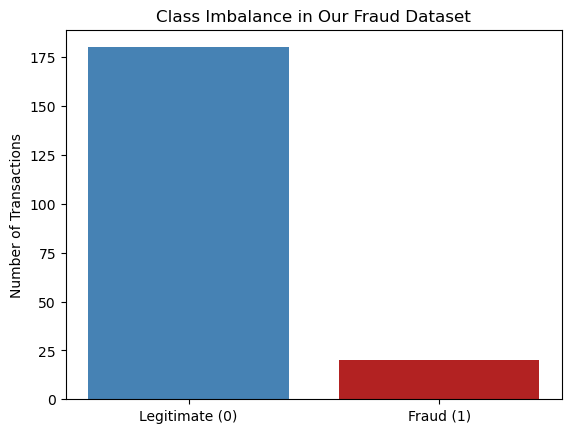

In [15]:
# Visualize the imbalance directly -- this is what "98% no, 2% yes" actually looks like.
counts = fraud_data["is_fraud"].value_counts().sort_index()

plt.bar(["Legitimate (0)", "Fraud (1)"], counts.values, color=["steelblue", "firebrick"])
plt.ylabel("Number of Transactions")
plt.title("Class Imbalance in Our Fraud Dataset")

plt.show()

In [16]:
# Prepare X and y, then split -- same workflow as always.
X_fraud = fraud_data[["amount"]]
y_fraud = fraud_data["is_fraud"]

X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
    X_fraud, y_fraud, test_size=0.3, random_state=42, stratify=y_fraud
)
# stratify=y_fraud keeps the same fraud/legit ratio in both the train and test sets.

print("Test set size:", len(X_test_f))
print("Fraud cases in test set:", y_test_f.sum())

Test set size: 60
Fraud cases in test set: 6


In [17]:
# Train a REAL model -- it actually looks at the "amount" feature to learn a pattern.
real_model = LogisticRegression()
real_model.fit(X_train_f, y_train_f)
real_predictions = real_model.predict(X_test_f)

# Train a DUMMY model -- it looks at nothing, and just always predicts the majority class ("legit").
dummy_model = DummyClassifier(strategy="most_frequent")
dummy_model.fit(X_train_f, y_train_f)
dummy_predictions = dummy_model.predict(X_test_f)

print("Real model trained. Dummy model trained (it just always guesses 'legit').")

Real model trained. Dummy model trained (it just always guesses 'legit').


In [18]:
# Compare accuracy alone, first -- this is the number that can fool you.
acc_real = accuracy_score(y_test_f, real_predictions)
acc_dummy = accuracy_score(y_test_f, dummy_predictions)

print(f"Real model accuracy:  {acc_real:.3f}")
print(f"Dummy model accuracy: {acc_dummy:.3f}")

Real model accuracy:  0.917
Dummy model accuracy: 0.900


Notice how close those two accuracy numbers are — maybe even in favor of the dummy model! On paper, "always say legit" looks almost as good as a real model. Now let's check recall, the metric that actually matters for catching fraud.

In [19]:
# Now the metric that matters: recall for the FRAUD class.
# zero_division=0 handles the case where the dummy model never predicts fraud at all.
recall_real = recall_score(y_test_f, real_predictions, zero_division=0)
recall_dummy = recall_score(y_test_f, dummy_predictions, zero_division=0)

print(f"Real model recall (catches this % of actual fraud):  {recall_real:.3f}")
print(f"Dummy model recall (catches this % of actual fraud):  {recall_dummy:.3f}")

Real model recall (catches this % of actual fraud):  0.167
Dummy model recall (catches this % of actual fraud):  0.000


There it is: the dummy model's recall is **0.0** — it catches zero real fraud cases, ever, no matter how good its accuracy looked a moment ago. This is exactly why accuracy alone is not enough on imbalanced data.

In [20]:
# classification_report is a scikit-learn shortcut that prints precision, recall, F1,
# and support (how many real examples of each class) all at once, per class.
print("--- Real model ---")
print(classification_report(y_test_f, real_predictions, target_names=["Legit", "Fraud"], zero_division=0))

print("--- Dummy model ---")
print(classification_report(y_test_f, dummy_predictions, target_names=["Legit", "Fraud"], zero_division=0))

--- Real model ---
              precision    recall  f1-score   support

       Legit       0.92      1.00      0.96        54
       Fraud       1.00      0.17      0.29         6

    accuracy                           0.92        60
   macro avg       0.96      0.58      0.62        60
weighted avg       0.92      0.92      0.89        60

--- Dummy model ---
              precision    recall  f1-score   support

       Legit       0.90      1.00      0.95        54
       Fraud       0.00      0.00      0.00         6

    accuracy                           0.90        60
   macro avg       0.45      0.50      0.47        60
weighted avg       0.81      0.90      0.85        60



# Part 5 — The Precision/Recall Trade-off: Sweeping the Threshold

Everything above used the default 0.5 threshold. Let's move that threshold across a whole range of values and watch precision and recall trade off, live.

In [21]:
# Get the real model's raw probability of "fraud" for every transaction in the test set.
fraud_probabilities = real_model.predict_proba(X_test_f)[:, 1]

# Try 17 different thresholds, evenly spaced from 0.1 to 0.9.
thresholds = np.arange(0.1, 0.95, 0.05)

results = []   # we'll collect one row per threshold

for t in thresholds:
    # Apply this threshold by hand: predict "fraud" (1) only if probability >= t.
    preds_at_t = (fraud_probabilities >= t).astype(int)

    # Compute precision, recall, and F1 at this specific threshold.
    p = precision_score(y_test_f, preds_at_t, zero_division=0)
    r = recall_score(y_test_f, preds_at_t, zero_division=0)
    f = f1_score(y_test_f, preds_at_t, zero_division=0)

    results.append({"threshold": round(t, 2), "precision": p, "recall": r, "f1": f})

# Turn the collected results into a table so we can inspect or plot them.
threshold_df = pd.DataFrame(results)
threshold_df

,threshold,precision,recall,f1
0,0.10,0.285714,0.666667,0.400000
1,0.15,0.363636,0.666667,0.470588
2,0.20,0.400000,0.666667,0.500000
3,0.25,0.444444,0.666667,0.533333
4,0.30,0.800000,0.666667,0.727273
5,0.35,0.750000,0.500000,0.600000
6,0.40,1.000000,0.333333,0.500000
7,0.45,1.000000,0.333333,0.500000
8,0.50,1.000000,0.166667,0.285714
9,0.55,0.000000,0.000000,0.000000


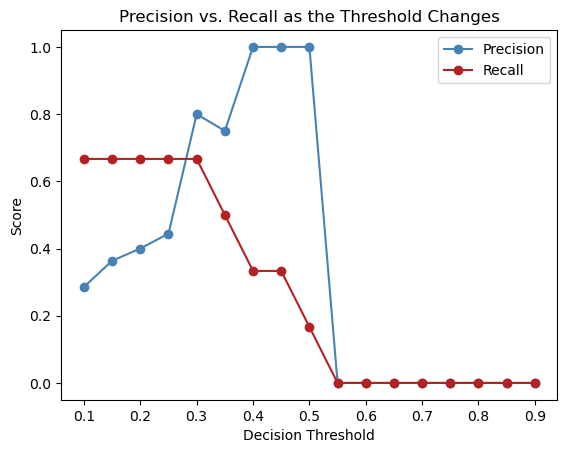

In [22]:
# Plot precision and recall as the threshold changes -- this is the trade-off, made visible.
plt.plot(threshold_df["threshold"], threshold_df["precision"], color="steelblue", marker="o", label="Precision")
plt.plot(threshold_df["threshold"], threshold_df["recall"], color="firebrick", marker="o", label="Recall")

plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.title("Precision vs. Recall as the Threshold Changes")
plt.legend()

plt.show()

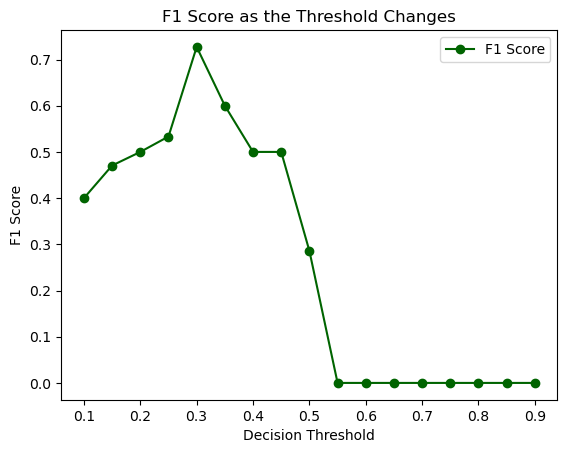

Best threshold for F1: 0.3 (F1 = 0.727)


In [23]:
# Plot F1 score across the same range, and find the threshold that maximizes it.
plt.plot(threshold_df["threshold"], threshold_df["f1"], color="darkgreen", marker="o", label="F1 Score")

plt.xlabel("Decision Threshold")
plt.ylabel("F1 Score")
plt.title("F1 Score as the Threshold Changes")
plt.legend()

plt.show()

# idxmax() finds the row with the highest F1 score.
best_row = threshold_df.loc[threshold_df["f1"].idxmax()]
print(f"Best threshold for F1: {best_row['threshold']} (F1 = {best_row['f1']:.3f})")

## Try a Custom Threshold Yourself

In [24]:
# Let's manually apply one specific threshold and see the full picture: confusion matrix + all four metrics.
# Try changing this value (e.g. to 0.3 or 0.7) and re-running the cell to feel the trade-off yourself.
custom_threshold = 0.3

custom_predictions = (fraud_probabilities >= custom_threshold).astype(int)

print(f"--- Results at threshold = {custom_threshold} ---")
print("Confusion matrix (rows=actual, columns=predicted):")
print(confusion_matrix(y_test_f, custom_predictions))
print()
print("Accuracy: ", round(accuracy_score(y_test_f, custom_predictions), 3))
print("Precision:", round(precision_score(y_test_f, custom_predictions, zero_division=0), 3))
print("Recall:   ", round(recall_score(y_test_f, custom_predictions, zero_division=0), 3))
print("F1 Score: ", round(f1_score(y_test_f, custom_predictions, zero_division=0), 3))

--- Results at threshold = 0.3 ---
Confusion matrix (rows=actual, columns=predicted):
[[53  1]
 [ 2  4]]

Accuracy:  0.95
Precision: 0.8
Recall:    0.667
F1 Score:  0.727


## Recap

- **Confusion matrix**: every metric today comes from just four numbers -- TP, TN, FP, FN.
- **Accuracy** = (TP+TN) / Total -- easy to read, easy to be fooled by on imbalanced data.
- **Precision** = TP / (TP+FP) -- of our "yes" calls, how many were right.
- **Recall** = TP / (TP+FN) -- of the real "yes" cases, how many we caught.
- **F1 Score** = harmonic mean of precision and recall -- one balanced number.
- **The threshold** controls the precision/recall trade-off -- there's no single "correct" value, it depends on which mistake costs more in your specific problem.

### Try It Yourself (optional)

1. Change `custom_threshold` above to a few different values and watch recall and precision move in opposite directions.
2. In the fraud dataset, change `scale=40` (the spread of fraud amounts) to `scale=15` — making fraud look more like legit transactions — and re-run everything. What happens to recall?
3. Try building a small classification_report for the very first pass/fail model from Part 1.